In [1]:
import VMBQC_functions
from VMBQC_functions import *

In [2]:
torch.cuda.is_available()

True

In [3]:
# Hyperparameters

# Pennylane devices have inbuild command names "shots" which is number of samples for a specific circuit architecture
N=10 # number of "shots"

samples=8000 # Total number of samples from MBQC-CQCA (includes the "shots" for each circuit with different byproducts)
target_samples = samples
runs=int(samples/N) # Number of times our model should run (at each of this "runs", the specific pennylane circuit provides N=10 "shots" / samples)

qubits=7
depth=4
layers=depth

##  Learning models

In [4]:


dev = qml.device("default.mixed", wires=qubits,shots=target_samples)

@qml.qnode(dev)
def target_emodel(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas
    
    # Design of the fully corrected CQCA
    
    [qml.Hadamard(wires=q) for q in range(qubits)]
    

    for l in range(depth): 
        
        
        for q in range(qubits):
            qml.RZ(t[qubits*l+q],wires=q)
            
       
            
        
        for q in range(qubits):
            if q<qubits-1:
                qml.CZ(wires=[q,q+1])
        qml.CZ(wires=[0,qubits-1])  

        for q in range(qubits):
            qml.Hadamard(wires=q)

            qml.BitFlip((1-sigmoid(p[qubits*l+q]))/2,wires=q)
    
    return qml.sample()


# Here we build the fully corrected CQCA circuit which gives a pure state. 

dev = qml.device("default.qubit", wires=qubits,shots=samples)

@qml.qnode(dev)
def eqv_circ_st(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas
    
    # Design of the fully corrected CQCA
    
    [qml.Hadamard(wires=q) for q in range(qubits)]
    

    for l in range(depth): 
        
        
        for q in range(qubits):
            qml.RZ(t[qubits*l+q],wires=q)
            
       
            
        
        for q in range(qubits):
            if q<qubits-1:
                qml.CZ(wires=[q,q+1])
        qml.CZ(wires=[0,qubits-1])  

        for q in range(qubits):
            qml.Hadamard(wires=q)

    
    return qml.sample()

In [5]:
# Similar to the above cell we initialize our main model \tilde{\epsilon}_c with the hyperparameters
model=VMBQC(qubits,layers,N)


In [6]:
def sample_circ(par):
    
    binary_array = np.array(eqv_circ_st(par))
    # binary_array = np.array(target_emodel(par))
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list

# def sample_circ_target_emodel(par):
    
#     binary_array = np.array(target_emodel(par))
#     #print(binary_array)
#     powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
#     decimal_array = np.sum(binary_array * powers_of_two, axis=1)
#     decimal_list = decimal_array.tolist()
    
#     return decimal_list


#####   For model 2

'''
Activate the below part when model \tilde{\epsilon}_c is in action and comment the part above to avoid any overlap and do the reverse if needed.
'''
# # function to get a single (1) (or, N = shots) number of data sample(s) from a single run of CQCA with given correction probabilities (p)
def get_samples_jl(runs, params):
    arr=[]
    p=params[:qubits*depth] #np.repeat(params[:1],qubits*depth) # cause you only have one probability parameter

    t=params[len(p):] 
    
    arr.append(model.corrected_machine_f2(p,t))
    return np.concatenate(arr)


# # function to get m (e.g. "runs=20000/10=2000") number of data samples from our model
# def sample_circ(par):
    
#     # usinf joblib to parallalize the process of generating sufficient samples
#     results = Parallel(n_jobs = 20)(delayed(get_samples_jl)(r, par) for r in range(runs))
#     s_a=list(itertools.chain.from_iterable(results))
#     binary_array = np.array(s_a)
#     #print(binary_array)
#     powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
#     decimal_array = np.sum(binary_array * powers_of_two, axis=1)
#     decimal_list = decimal_array.tolist()
    
#     return decimal_list

def sample_circ_target_emodel(par):
    
    # usinf joblib to parallalize the process of generating sufficient samples
    results = Parallel(n_jobs = 20)(delayed(get_samples_jl)(r, par) for r in range(runs))
    s_a=list(itertools.chain.from_iterable(results))
    binary_array = np.array(s_a)
    #print(binary_array)
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list
    


# Testing the analytical result in vmbqc paper

Keep the $\theta$s fixed and see the effect of the $p_c$s

In [7]:
t2=np.array([0.18286705, 0.33836669, 0.41568225, 0.5854143 , 0.48569439,
        0.77811321, 0.98589481, 0.99935661, 0.94416145, 0.68680775,
        0.792978  , 0.05498088, 0.85775363, 0.98149554, 0.92817743,
        0.34892816, 0.90251013, 0.51903018, 0.02470978, 0.28787715,
        0.23570746, 0.40766506, 0.14703871, 0.68891518, 0.65566425,
        0.70376405, 0.41210062, 0.81588872])

#np.random.uniform(0,1,qubits*depth)

In [8]:
t2

tensor([0.18286705, 0.33836669, 0.41568225, 0.5854143 , 0.48569439,
        0.77811321, 0.98589481, 0.99935661, 0.94416145, 0.68680775,
        0.792978  , 0.05498088, 0.85775363, 0.98149554, 0.92817743,
        0.34892816, 0.90251013, 0.51903018, 0.02470978, 0.28787715,
        0.23570746, 0.40766506, 0.14703871, 0.68891518, 0.65566425,
        0.70376405, 0.41210062, 0.81588872], requires_grad=True)

In [4]:
# init_test_p = np.loadtxt(f'new_models/target_param_1_p_pos:{k}')
# init_test_p


k=[2+qubits,4+qubits] #[1,3,5,9,11]
p2=np.ones((qubits*depth))
p2[k]=np.random.uniform(.1,0.1,1) #np.random.uniform(.25,0.25,1)
p2

tensor([1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 0.1, 1. , 0.1, 1. ,
        1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
        1. , 1. ], requires_grad=True)

3.9209399223327637 sec


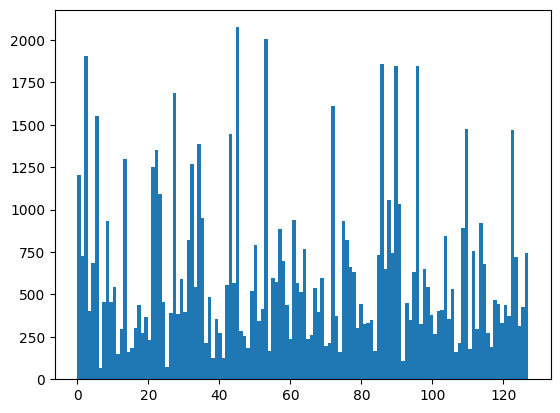

In [11]:
# def target_circuit(init_para):  
    
#     return sample_circ_target_emodel(init_para)



def target_circuit(init_para):  
    
    results = Parallel(n_jobs = 30)(delayed(get_samples_jl)(r, init_para) for r in range(target_samples))
    s_a=list(itertools.chain.from_iterable(results))
    binary_array = np.array(s_a)
    #print(binary_array)
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list


init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
s=time.time()
f_s_t=plt.hist(target_circuit(init_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')


In [12]:
(init_para)

tensor([        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf, -2.19722458,
                inf, -2.19722458,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,  0.18286705,  0.33836669,
         0.41568225,  0.5854143 ,  0.48569439,  0.77811321,  0.98589481,
         0.99935661,  0.94416145,  0.68680775,  0.792978  ,  0.05498088,
         0.85775363,  0.98149554,  0.92817743,  0.34892816,  0.90251013,
         0.51903018,  0.02470978,  0.28787715,  0.23570746,  0.40766506,
         0.14703871,  0.68891518,  0.65566425,  0.70376405,  0.41210062,
         0.81588872], requires_grad=True)

In [13]:
# np.savetxt(f'new_models/target_param_p_pos:{k}',init_para)
# init_test_p = np.loadtxt(f'new_models/target_param_p_pos:{k}')
# sigmoid(init_test_p[:qubits*depth])

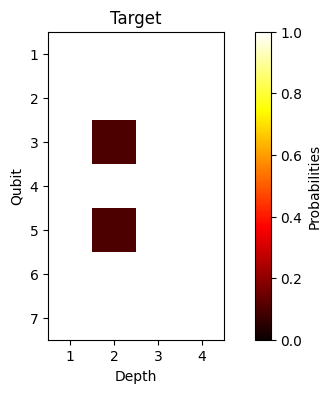

In [14]:
gen_prob_par(sigmoid(init_para[:qubits*depth]),qubits,depth,'Target')

In [15]:
# np.savetxt(f'target_param_layer_{k}_1_p',init_para)

In [16]:
pg=f_s_t[0]/(N*target_samples)
pg

array([0.0150375, 0.00905  , 0.0238   , 0.005025 , 0.0085375, 0.0194125,
       0.00085  , 0.005725 , 0.011675 , 0.0057   , 0.0068125, 0.0018875,
       0.003675 , 0.0162375, 0.0020125, 0.0022875, 0.0038   , 0.0054375,
       0.003375 , 0.004575 , 0.0028625, 0.015625 , 0.016925 , 0.0136375,
       0.005675 , 0.000925 , 0.00485  , 0.021125 , 0.0048125, 0.0073875,
       0.004975 , 0.0102625, 0.0158375, 0.0068125, 0.0173625, 0.0119   ,
       0.0026375, 0.0060875, 0.0015375, 0.0044625, 0.003425 , 0.0015375,
       0.0069375, 0.0181   , 0.007075 , 0.0259375, 0.0035875, 0.0031875,
       0.002325 , 0.0064875, 0.0099   , 0.004325 , 0.0051875, 0.0251   ,
       0.0021   , 0.0074625, 0.0071375, 0.0110375, 0.008725 , 0.0055   ,
       0.00295  , 0.0117625, 0.0070625, 0.0064125, 0.009625 , 0.0029625,
       0.0032375, 0.0067   , 0.0049625, 0.0074875, 0.0024375, 0.0026375,
       0.0201375, 0.004675 , 0.002    , 0.011675 , 0.0102625, 0.0082375,
       0.007875 , 0.0038125, 0.005525 , 0.00405  , 

In [6]:
# np.savetxt(f'target_dist_{k}_1_p',pg)

In [18]:
# sampling from target distribution e.g. mixed gaussian
def sample_target_function():
    x=range(2**qubits)
    ret = np.random.choice(x,samples,p=pg)
    return ret.copy()

0.08019351959228516 sec


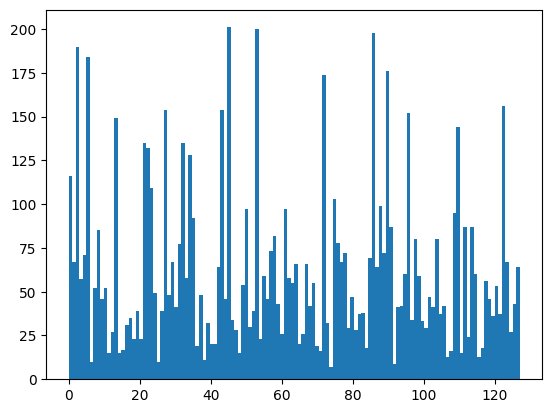

In [19]:
s=time.time()
opt_hist=plt.hist(sample_target_function(),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [20]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [21]:
# kernel function to calculate distance between two sample data points

def kernel_exp_torch(s1,s2):
    s1t = torch.tensor(s1, dtype = torch.float64).to(DEVICE)
    s2t = torch.tensor(s2, dtype = torch.float64).to(DEVICE)
    d1 = s1t.size(-1)
    d2 = s2t.size(-1)
    s1t = s1t.reshape([1,-1,1])
    s2t = s2t.reshape([1,-1,1])
    
    diffsquared = (torch.cdist(s1t,s2t,p=2.0).to(DEVICE))**2

    sigma_list=[0.5,4]
    exp = 0.0
    for sigma in sigma_list:
        expMatrix = torch.exp(diffsquared/(-2.0*sigma)).to(DEVICE)
        expMatrix = expMatrix/(len(sigma_list)*d1*d2)
        exp = exp + torch.sum(expMatrix).to(DEVICE)
        
    return exp

In [22]:
def mmd_loss(params):
    
    s2=sample_target_function()
    s1=sample_circ(params)
    res=kernel_exp_torch(s1,s1)-2*kernel_exp_torch(s1,s2)+kernel_exp_torch(s2,s2)
    return res.detach().cpu().numpy()


In [23]:
# Gradient for correction probabilities stated in eq. 17 of: https://arxiv.org/pdf/2310.13524.pdf

def mmd_grad_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    grad = torch.zeros(len(p)).to(DEVICE)
    
    
    
    sample_targ=sample_target_function()
    
    for i in range(len(p)):
        
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad[i]= grad[i]*inner_derivative
        p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])

        
    return grad


def mmd_grad_1layer_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    # grad = torch.zeros(len(p)).to(DEVICE)
    grad_1 = torch.zeros(len(p)).to(DEVICE)

    
    # d=2 # indicates the layer we would like to train
    # for pr,i in zip(p,range(qubits*(d-1),qubits*d)): # as you have only N prob that repeats across the first layer

    for i in range(len(p)):
        if p[i]!=torch.inf:
            
            sample_targ=sample_target_function()
            sample_y = sample_circ(params) ###############  eqv_circ_st(params)
            
            a=p[i].copy()
            inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
            
            p[i]=torch.tensor(100.0).numpy()
            
            sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
           
            
            p[i]=torch.tensor(-100.0).numpy()
            
            sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
            
            
            grad_1[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
            grad_1[i]= grad_1[i]*inner_derivative
            p[i]=a
        
        
    return grad_1
    
    
# Gradient for variational parameters \thetas stated in eq. 16 of: https://arxiv.org/pdf/2310.13524.pdf
    
def mmd_grad_theta(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    prob = sample_circ(params)
    grad = torch.zeros(len(thetas)).to(DEVICE)
    
    for i in range(len(thetas)):
        # pi/2 phase
        thetas[i] += np.pi/2.
        prob_pos = sample_circ(params) # p_{theta}^{+}
        # -pi/2 phase
        thetas[i] -= np.pi
        prob_neg = sample_circ(params) # p_{theta}^{-}
        
        t1=kernel_exp_torch(prob, prob_pos)
        
        t2=kernel_exp_torch(prob, prob_neg)

        t3=kernel_exp_torch(sample_target_function(), prob_pos)
        
        t4=kernel_exp_torch(sample_target_function(), prob_neg)

        
        grad_pos = t1 - t2
        grad_neg = t3 - t4
        grad[i] = (grad_pos - grad_neg).detach().cpu()
        
        thetas[i] += np.pi/2.0 #reset to original value
        
    return grad


# combined gradient of both sets of parameters

def mmd_grad(params):
    #probs=params[:int(len(params)/2)]
    #thetas=params[len(probs):]
    grad=torch.cat((mmd_grad_1layer_p_new(params),mmd_grad_theta(params)))
    return grad

In [24]:
'''
import torch
import gc
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
            print(obj.shape, type(obj), obj.size(), obj.device)
    except:
        pass
'''

"\nimport torch\nimport gc\nfor obj in gc.get_objects():\n    try:\n        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):\n            print(obj.shape, type(obj), obj.size(), obj.device)\n    except:\n        pass\n"

In [25]:
#torch.cuda.empty_cache()

In [26]:
#import gc

#gc.collect()
#torch.cuda.empty_cache()


In [27]:
# algorithm for gradient descent copied from : https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html

# We rewrote the algorithm with our approximate gradient calculated from samples instead of using the in-built exact gradient 

class GradientDescentOptimizer_mmd_2:  
    def __init__(self, stepsize): # if some value is given here itself then it will become a by default value
        self.stepsize = stepsize

    def step_and_cost(self, objective_fn, *args, grad_fn=None, **kwargs):
        
        g, forward = self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, args)

        if forward is None:
            forward = objective_fn(*args, **kwargs)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0], forward
        return new_args, forward


    def step(self, objective_fn, *args, train, grad_fn=None, **kwargs):
        
        p_len=int(len(args[0])/2)
        if train=='p':
            arg1=args[0][:int(len(args[0])/2)]
        else:
            arg1=args[0][int(len(args[0])/2):]
        
        g= self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, arg1,args,train)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0]

        return new_args

    @staticmethod
    def compute_grad(objective_fn, args, kwargs, grad_fn=None):
       
        
        grad = mmd_grad(*args).detach().cpu().numpy()
        

        num_trainable_args = sum(getattr(arg, "requires_grad", False) for arg in args)
        grad = (grad,) if num_trainable_args == 1 else grad
        #print('grads--',grad[0])
        return grad


    def apply_grad(self, grad, arg1,args,train):
        
        #print('arg1--',arg1)#################
        args_new = list(arg1)
        
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):

                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
        else:
            trained_index = p_len ########## need to be generalized
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
            
        
        #print('new args-->',args_new[0])#############
        
        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new]) # here we can do this only because the they have same size
        

In [28]:
# We use parts the above above algorithm to finally use the Adagrad optimization algorithm below to update our tunable parameters

from pennylane.numpy import sqrt
class AdagradOptimizer_mmd_2(GradientDescentOptimizer_mmd_2):
    

    def __init__(self, stepsize=0.01, eps=1e-8):
        super().__init__(stepsize)
        self.eps = eps
        self.accumulation = None

    def apply_grad(self, grad, arg1, args, train):
        
        p_len=int(len(args[0])/2)
        args_new = list(arg1)

        if self.accumulation is None:
            self.accumulation = [0.0] * len(arg1)
            
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
                    
        else:
            
            trained_index = p_len # need to be generalized
            
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
            
            

        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new])


    def _update_accumulation(self, index, grad):
        
        self.accumulation[index] = self.accumulation[index] + grad**2

    def reset(self):
        
        self.accumulation = None

In [29]:
def cost(par):

    c=mmd_loss(par) 
    return c

In [30]:

cost(init_para)

array(0.0040951)

In [7]:
k=[9, 11]

In [ ]:
runs_2=10
iterations=199  # next time if run the same experiment for more agents then iterations=199


## seeding 
import random
import os

# Set seed for reproducibility (before any random ops)
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
####### end of seeding



cost_arr=[]
params_arr=[]
for r in range(runs_2):
    # opt1 = AdagradOptimizer_mmd_2(stepsize=0.2)
    opt2 = AdagradOptimizer_mmd_2(stepsize=0.1)
    
    
    p2=np.ones((qubits*depth))
    # p2[k]=np.random.uniform(.89,.95,len(k))
    t2=np.random.uniform(0,1,qubits*depth)

    init_p = np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)

    # init_p=init_para
    params=init_p
    
    cost_arr.append(cost(init_p))
    params_arr.append(init_p)
    

    current_cost=[]
    
    for i in range(iterations):


        start=time.time()
        # params = opt1.step(cost, params,train='p')
        params = opt2.step(cost, params,train='t')
        end=time.time()
        current_cost.append(cost(params))
        cost_arr.append(current_cost[i])
        

        params_arr.append(params)
        #params_arr_tot_2.append(params)

        if i % 1 == 0:
            print(f"Cost at step {i}:", current_cost[i],f'of run:{r}')

            
            print('time taken-->',(end-start)/60,'min')

    
    
    np.savetxt(f'{k}_k_target_unit_learningmodel_depth:{depth}_loss_{r}.txt', cost_arr)
    np.savetxt(f'{k}_k_target_unit_learningmodel_depth:{depth}_par_{r}.txt', params_arr)

    

Cost at step 0: 0.006122757572698256 of run:0
time taken--> 0.09088418086369833 min
Cost at step 1: 0.0045178954152460295 of run:0
time taken--> 0.09041989247004191 min
Cost at step 2: 0.003939782025180045 of run:0
time taken--> 0.09245670636494954 min
Cost at step 3: 0.0034517286589899297 of run:0
time taken--> 0.0906969944636027 min
Cost at step 4: 0.003156875974248175 of run:0
time taken--> 0.09100873470306396 min
Cost at step 5: 0.003007881654898247 of run:0
time taken--> 0.09081772168477377 min
Cost at step 6: 0.0030616426145920195 of run:0
time taken--> 0.09075948397318521 min
Cost at step 7: 0.0029957890802738835 of run:0
time taken--> 0.09093159437179565 min
Cost at step 8: 0.0025403221987411566 of run:0
time taken--> 0.08970184326171875 min
Cost at step 9: 0.0027276927111742066 of run:0
time taken--> 0.09020918607711792 min
Cost at step 10: 0.0025124020263307713 of run:0
time taken--> 0.09223372936248779 min
Cost at step 11: 0.0023042359233348686 of run:0
time taken--> 0.09075

In [8]:
c_t = np.loadtxt(f'{k}_k_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
c_t.min()

tensor(0.00039693, requires_grad=True)

In [33]:
min(cost_arr)

array(0.00077217)

In [78]:
init_para

tensor([       inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
        0.14873864, 0.44027239, 2.58745491, 0.1267443 , 3.11927184,
        1.03648447, 0.69008703, 2.08263697, 1.75245546, 3.282719  ,
        3.95966109, 2.31115676, 4.75230571, 4.40046353, 4.594936  ,
        2.60775363, 5.66213463, 3.16729935, 2.05343041, 5.69646636,
        0.39636656, 2.95665434, 0.94794676, 0.79972337, 3.54375705,
        1.53060474, 5.3900941 , 2.5836044 , 1.7767493 , 0.53743432,
        5.30743368, 1.68844648, 0.40466298, 1.65169323, 0.66979819], requires_grad=True)

In [539]:
# k=[1,3,5]
# c_t = np.loadtxt(f'{k}_qubit_pt_target_unit_learningmodel_depth:{depth}_loss_{19}.txt')
# c_t.min()

In [8]:
p_t=np.loadtxt(f'{k}_qubit_pt_target_unit_learningmodel_depth:{depth}_par_{9}.txt')
p_t

(2000, 56)

In [27]:
sigmoid(params_arr[-1][:qubits*depth])

tensor([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.89631904, 0.93783228, 0.92144415,
        0.91171313, 0.88032662, 0.88174309, 0.87369327, 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ], requires_grad=True)

The deeper we set the byproducts (in the layers) the lesser the non-trivial effect from the byproducts we get on the 
qubits

In [6]:
# k=range(qubits)
# c_t = np.loadtxt(f'new_models/layerwise_learning/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_loss_{9}.txt')
# c_t.min()


# d=1 # only for d=1
# k=range(qubits*(d-1),qubits*d)
# c_t = np.loadtxt(f'{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_loss_{9}.txt')
# c_t.min()



d=3
k=range(qubits*(d-1),qubits*d)
c_t = np.loadtxt(f'{qubits}_qubit_pt_target_{k}:k_emodel_depth:{depth}_loss_{9}.txt')
c_t.min()

tensor(0.00054771, requires_grad=True)

In [47]:
# c_t = np.loadtxt(f'new_models/qubitwise_target/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_loss_{9}.txt')
# c_t.min()

In [8]:
torch.argmin(torch.tensor(c_t))

tensor(143)

In [9]:
# p_t=np.loadtxt(f'new_models/layerwise_learning/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_par_{9}.txt')
p_t=np.loadtxt(f'{qubits}_qubit_pt_target_{k}:k_emodel_depth:{depth}_par_{9}.txt')

In [11]:
opt_p=p_t[torch.argmin(torch.tensor(c_t))][:qubits*depth]

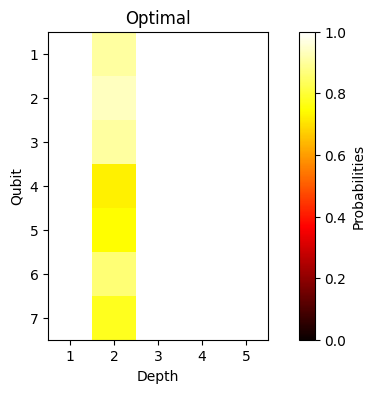

In [12]:
gen_prob_par(sigmoid(opt_p),qubits,depth,'Optimal')

Make sure to set the P_c's =1 to make sure that the optimal loss is due to the correction 
probabilities and not just because of the thetas!

In [86]:
p_t[-3][:qubits*depth]=np.inf
p_t[-3]

tensor([        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
         0.69221078,  4.03081626,  5.69303328,  4.23807896,  7.08883893,
         3.15212063,  5.17204009, -0.17606203,  3.68568488,  1.10197851,
         5.37632519,  3.48956522,  3.97607428,  1.4364078 ,  4.12855398,
         1.62038084,  5.74560748,  0.9398544 ,  2.67725952,  2.04688569,
         1.12321354,  3.7908646 ,  1.55333301,  5.39889689,  4.67693411,
         5.71854951,  4.31646394,  6.92777189,  3.63631477,  0.8615313 ,
         5.56348356,  2.84914641,  2.76974087,  2.1

In [88]:
cost(p_t[-3])

array(0.00293083)

0.13273334503173828 sec


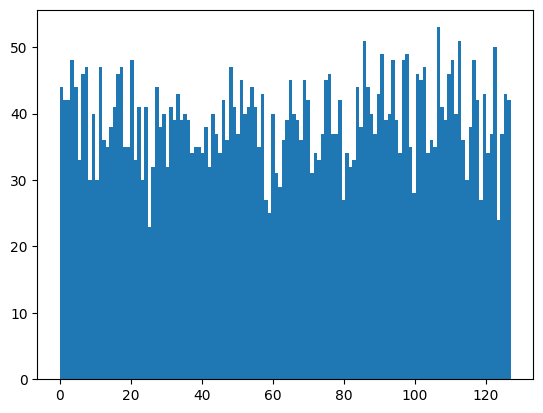

In [203]:
s=time.time()
opt_hist=plt.hist(sample_circ((params_arr[cost_arr.index(min(cost_arr))])),bins=2**qubits)
e=time.time()
print(e-s,'sec')

0.26894497871398926 sec


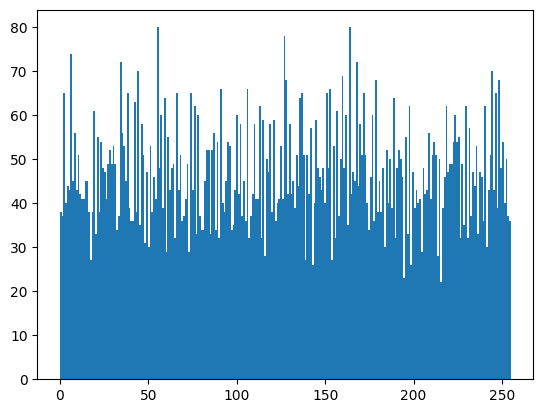

In [1241]:
opt_para= params_arr[0]
s=time.time()
f_s_t=plt.hist(sample_circ_target_emodel(opt_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [946]:
(params_arr)

47

In [959]:
(params_arr[30])

tensor([ 2.23924088e-01,  3.15306465e+00,  1.62554486e+00,
         1.52034051e+00,  1.55128823e+00, -4.00950782e-04,
         1.57149626e+00,  1.59206050e+00, -9.29160380e-02,
         3.15921677e+00,  3.13727447e+00,  2.59256481e+00,
         1.52917853e+00, -2.96319425e-02,  1.59379459e+00,
         1.74212997e+00,  1.52050070e+00,  1.59218744e+00,
         6.01384311e-01,  1.62339556e+00,  1.56837980e+00,
         1.61248737e+00,  1.58862306e+00,  1.51735062e+00], requires_grad=True)

Plots ideas:

Do not make the plot of comparision between etilde vs unitary learning; instead it should be
unitary vs unitary when in one scenario the target is generated from unitary and in the 
other case the target is generated using the same thetas but add to that we have $p_c$ which
makes the output dist. hardar for the unitary.

# For qubit-wise target model, put the byproducts on the middle qubit so that it has non trivial effect on all qubits when it reaches the last layer!

## Testing of the loss

In [73]:
c_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_loss_{0}.txt')
c_t.min()

tensor(0.00059127, requires_grad=True)

In [20]:
p_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt')
sigmoid(p_t[-1])

tensor([0.8449098 , 0.98696726, 0.93087352, 0.89801162, 0.79555444,
        0.79554912, 0.77416647, 0.96495418, 0.89860828, 0.92490551,
        0.76609255, 0.99202554, 0.95628839, 0.8080558 , 0.80126412,
        0.80161461, 0.82877979, 0.88021249, 0.85826446, 0.82582056,
        0.72444348, 0.38661631, 0.68023842, 0.55542909, 0.68506884,
        0.80186974, 0.64297915, 0.658578  , 0.70664503, 0.4845197 ,
        0.54616914, 0.34221669, 0.44806727, 0.79538243, 0.77070985,
        0.83995806, 0.655738  , 0.84648353, 0.6884188 , 0.78171101], requires_grad=True)

In [74]:
from matplotlib.animation import FuncAnimation, PillowWriter


def load_and_reshape(txt_file):
    arr = sigmoid(np.loadtxt(txt_file)[:, :qubits * depth])
    if arr.ndim != 2 or arr.shape[1] != depth*qubits:
        raise ValueError("Expected (n_frames, 56) shape")
    # Reshape to (frames, rows=7, cols=8) — which matches your arr.reshape(-1,7,8)
    return arr.reshape(-1, depth, qubits)

def animate_grid(frames, output=f'new_models/p_evol_plots/{k}_qubit_p_target_etilde_learningmodel.gif', fps=10, cmap='hot'):
    n_frames, rows, cols = frames.shape  # rows=7, cols=8
    fig, ax = plt.subplots()
    
    # Transpose the first frame for correct axes orientation
    im = ax.imshow(frames[0].T,
                   vmin=frames.min(), vmax=frames.max(),
                   cmap=cmap, aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Probabilities')
    ax.set_title(f'Frame 1/{n_frames}')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Qubit')

    def update(i):
        im.set_data(frames[i].T)  # Transpose each frame before plotting
        ax.set_title(f'Evolution of probs at epoch {i+1}/{n_frames}')
        return (im,)

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=1000/fps, blit=True)
    writer = PillowWriter(fps=fps)
    anim.save(output, writer=writer)
    plt.close(fig)
    print(f"✅ GIF saved as '{output}'")

if __name__ == "__main__":
    data3d = load_and_reshape(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt'
                             )
    animate_grid(data3d, fps=10)

✅ GIF saved as 'new_models/p_evol_plots/0_qubit_p_target_etilde_learningmodel.gif'


In [98]:
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_loss.txt', cost_arr)
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_par.txt', params_arr)

In [6]:
par_model = np.loadtxt(f'etilde_5q_etilde_all_same_p_target_par_{4}.txt')

In [55]:
sigmoid(params_arr[-1])

tensor([0.89734693, 0.99183773, 0.95576729, 0.93389926, 0.86195247,
        0.86194857, 0.84616755, 0.97786667, 0.93430133, 0.95183728,
        0.84013622, 0.99501522, 0.97230211, 0.87105183, 0.86611986,
        0.86637505, 0.88593433, 0.921818  , 0.90668497, 0.88382444,
        0.6708102 , 0.50987329, 0.59679844, 0.61452177, 0.63554228,
        0.70789352, 0.52490523, 0.64890594, 0.66650153, 0.48661639,
        0.66985786, 0.5176338 , 0.49126563, 0.74056075, 0.37632773,
        0.71267199, 0.59979526, 0.499436  , 0.68659142, 0.63182744], requires_grad=True)

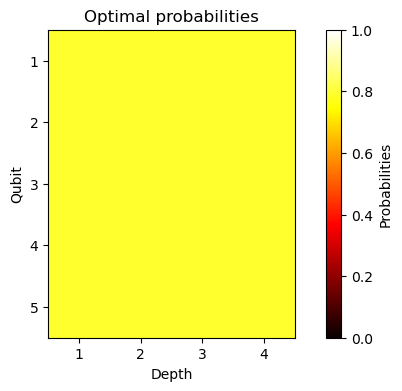

In [8]:
gen_prob_par(par_model[-1][:qubits*depth],qubits,depth)

In [785]:
cost_channel_target = np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_unit_learningmodel_loss_{4}.txt')
cost_channel_target.shape

(1000,)

In [799]:
cost_channel_target[:200]

tensor([0.05421503, 0.03850735, 0.02095143, 0.01489375, 0.00952386,
        0.00607734, 0.00429791, 0.005213  , 0.00419301, 0.00458129,
        0.00435567, 0.00365019, 0.00258474, 0.00350518, 0.0026983 ,
        0.00290786, 0.00336054, 0.00256478, 0.00207736, 0.00216366,
        0.00240381, 0.00286678, 0.00244549, 0.00198848, 0.00195944,
        0.00223772, 0.00177095, 0.00234615, 0.00207199, 0.00236809,
        0.00173223, 0.00174109, 0.00204599, 0.00149069, 0.00200329,
        0.00171619, 0.00195475, 0.00187765, 0.00203812, 0.00168964,
        0.00162466, 0.00178552, 0.00184245, 0.00217061, 0.00182756,
        0.00202922, 0.00168082, 0.00135248, 0.00186408, 0.00258813,
        0.00228841, 0.00175759, 0.00238944, 0.001282  , 0.00155067,
        0.00151754, 0.00193157, 0.00177404, 0.0017899 , 0.00121984,
        0.0018081 , 0.0020455 , 0.00202657, 0.00187043, 0.00151638,
        0.00153833, 0.00156621, 0.00237812, 0.00218911, 0.00127614,
        0.00207027, 0.00120094, 0.00137075, 0.00

In [794]:
cost_channel_target.min()

tensor(0.00066775, requires_grad=True)

In [795]:
cost_unit_target = np.loadtxt(f'new_models/qubitwise_target/unit_target_unit_learningmodel_loss_{4}.txt')
cost_unit_target.min()

tensor(0.00046734, requires_grad=True)

In [800]:
cost_unit_target[:200]

tensor([0.11200129, 0.07922287, 0.06322121, 0.04795331, 0.03363409,
        0.02371302, 0.01735112, 0.01285907, 0.00914898, 0.00534169,
        0.00430852, 0.00468036, 0.00283431, 0.0033728 , 0.00301447,
        0.00264991, 0.00275133, 0.00221101, 0.00158484, 0.00193348,
        0.00205514, 0.00310071, 0.00203717, 0.00195564, 0.00160935,
        0.00160951, 0.00108001, 0.00185753, 0.00215449, 0.00130635,
        0.00128562, 0.00121872, 0.00100867, 0.00185412, 0.00142701,
        0.00122438, 0.00167464, 0.00154832, 0.00145519, 0.00186811,
        0.00155284, 0.00146982, 0.00179954, 0.00216424, 0.00147452,
        0.00117127, 0.00135013, 0.0014096 , 0.00153836, 0.00146082,
        0.00140576, 0.00135788, 0.00100152, 0.00108709, 0.00122515,
        0.001154  , 0.00093558, 0.00103369, 0.00165848, 0.00106538,
        0.00190281, 0.00099547, 0.00109051, 0.00105161, 0.00097979,
        0.00134383, 0.0012657 , 0.00087991, 0.00090483, 0.00080105,
        0.00119594, 0.00134895, 0.00121688, 0.00

In [801]:
ave_cost=[]
std=[]
a=[]
total_cost_arr=[]


runs_2=1
iterations=199
for r in range(runs_2):
    total_cost_arr.append(cost_channel_target[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a=[]
    for i in range(runs_2):
        a.append(total_cost_arr[i][j])
    std.append(np.std(a))
    ave_cost.append(np.average(a))


    
ave_cost_1=[]
std_1=[]
a_1=[]
total_cost_arr_1=[]


runs_2=1
iterations=199
for r in range(runs_2):
    total_cost_arr_1.append(cost_unit_target[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_1=[]
    for i in range(runs_2):
        a_1.append(total_cost_arr_1[i][j])
    std_1.append(np.std(a_1))
    ave_cost_1.append(np.average(a_1))



/tmp/ipykernel_3796181/3089332358.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y, 'k', color='navy',label='$\widetilde{\mathcal{E}}_c(p=1/2)$')
/tmp/ipykernel_3796181/3089332358.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='$U_c$')


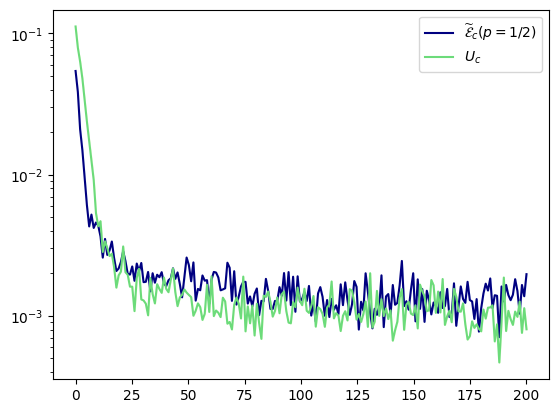

In [802]:
fig, ax = plt.subplots()
x=np.linspace(0,iterations+1,iterations+1)
y=ave_cost
yerr=std

y_1=ave_cost_1
yerr_1=std_1


ax.semilogy(x, y, 'k', color='navy',label='$\widetilde{\mathcal{E}}_c(p=1/2)$')
ax.fill_between(x, np.array(y)+np.array(yerr)/2,np.array(y)+(-1)*np.array(yerr)/2,
    alpha=0.1, edgecolor='dodgerblue', facecolor='dodgerblue')

ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='$U_c$')
ax.fill_between(x, np.array(y_1)+np.array(yerr_1),np.array(y_1)+(-1)*np.array(yerr_1),
    alpha=0.1, edgecolor='#7FFF00', facecolor='#7FFF00')
# plt.title(r'Target distribution: $\widetilde{\epsilon}_{c}(p=\sim0.7)$')
# plt.ylim(0.00000007,0.1)
plt.legend()
plt.show()

In [103]:
########## ******  The actual plot with 4 graphs of double gaussian is available in my desktop and not in gorka's workstation

In [272]:

import gc

mmd_grad(params).cpu()
del mmd_grad
gc.collect()
torch.cuda.empty_cache()
